# Goal: Analyse if there is any correlation between the ammount of duplicates the code snippet sample and the f1-scores obtained for all the projects

In [1]:
import sys
sys.path.append("..")

from utils import read_data

In [2]:
from utils import read_data

DF_FOLDER_PATH = "../../code snippets-with-labels&metrics"
GRANULARITIES = ['file', 'class', 'method', 'block']

# got this list ffrom the authors github repository
PROJECTS = [
    "antlr4-4.11.0", "dbeaver-22.2.5", "elasticsearch-8.5.2", "exoplayer-2.18.2",
    "fastjson-1.2.83", "flink-1.15.3", "guava-31.1", "jenkins-2.379", "libgdx-1.11.0", 
    "logstash-8.5.2", "mockito-4.9.0", "openrefine-3.6.2", "presto-0.278", 
    "quarkus-2.14.0", "questdb-6.6", "redisson-3.18.1", "rxjava-3.1.5", "tink-1.7.0"
]

data = read_data(GRANULARITIES=GRANULARITIES, DF_FOLDER_PATH = DF_FOLDER_PATH, PROJECTS = PROJECTS)

100%|██████████| 4/4 [00:08<00:00,  2.20s/it]


In [3]:
data, GRANULARITIES, PROJECTS

sys.path.append("../..")
from project_Info import file_feature_names_lowercase, class_feature_names_lowercase, method_feature_names_lowercase, block_feature_names_lowercase 

features = {
    "file": file_feature_names_lowercase,
    "class": class_feature_names_lowercase,
    "method": method_feature_names_lowercase,
    "block": block_feature_names_lowercase
}

In [4]:
# Verifying the presence of duplicates by project considering only the metrics

from tqdm import tqdm


dups_by_project = {} 

project_with_duplicates_count = 0
for granularity in tqdm(GRANULARITIES, desc="Granularities"):
    dups_by_project[granularity] = {}
    for project in tqdm(data[granularity].keys(), desc=f"Projects ({granularity})", leave=False):
        df = data[granularity][project]
        df.columns = [column.lower() for column in df.columns]

        X = df[features[granularity]]
        # y = df['CommentsAssociatedLabel'.lower()]

        # diff = len(X) - len(set(X))
        dups = X.duplicated().sum()

        dups_by_project[granularity][project] = {"duplicate_count": dups, "length": len(X)} 

        if dups > 0: 
            print(f"{dups} out of {len(X)} are duplicates")
            project_with_duplicates_count += 1

print()
print(f"{project_with_duplicates_count} out of {18 * 4} projects have at least one duplicate")


Granularities:  25%|██▌       | 1/4 [00:00<00:00,  9.76it/s]

34 out of 507 are duplicates
164 out of 4726 are duplicates
612 out of 14066 are duplicates
3 out of 1399 are duplicates
51 out of 1051 are duplicates
310 out of 13075 are duplicates
20 out of 1498 are duplicates
14 out of 1624 are duplicates
169 out of 2198 are duplicates
21 out of 505 are duplicates
14 out of 897 are duplicates
53 out of 935 are duplicates
284 out of 7877 are duplicates
215 out of 5668 are duplicates
319 out of 2453 are duplicates
77 out of 1378 are duplicates
94 out of 1857 are duplicates
11 out of 631 are duplicates


17 out of 428 are duplicates
97 out of 3999 are duplicates
239 out of 10825 are duplicates
18 out of 2158 are duplicates
62 out of 1118 are duplicates
771 out of 16473 are duplicates
63 out of 2313 are duplicates
16 out of 2142 are duplicates
105 out of 2143 are duplicates
14 out of 446 are duplicates
7 out of 656 are duplicates
4 out of 554 are duplicates
23 out of 3675 are duplicates
272 out of 6412 are duplicates
21 out of 1036 are duplicates
59 out of 1220 are duplicates
47 out of 1162 are duplicates
23 out of 737 are duplicates


87 out of 1283 are duplicates
604 out of 5565 are duplicates
5367 out of 27447 are duplicates
1299 out of 10562 are duplicates


Granularities:  75%|███████▌  | 3/4 [00:00<00:00, 11.28it/s]

352 out of 1287 are duplicates
5091 out of 28092 are duplicates
1295 out of 8344 are duplicates
443 out of 6637 are duplicates
1719 out of 7282 are duplicates
35 out of 809 are duplicates
178 out of 1632 are duplicates
68 out of 1328 are duplicates
675 out of 8423 are duplicates
2769 out of 11355 are duplicates
315 out of 3202 are duplicates
3354 out of 4790 are duplicates
605 out of 3858 are duplicates
170 out of 2038 are duplicates


473 out of 1122 are duplicates
1550 out of 5042 are duplicates
11197 out of 22336 are duplicates
6857 out of 10897 are duplicates
781 out of 1327 are duplicates


Granularities: 100%|██████████| 4/4 [00:00<00:00, 10.73it/s]

12452 out of 22053 are duplicates
6230 out of 8262 are duplicates
2202 out of 4354 are duplicates
1475 out of 2860 are duplicates
204 out of 566 are duplicates
1226 out of 1816 are duplicates
347 out of 1081 are duplicates
6896 out of 12178 are duplicates
4242 out of 8580 are duplicates
1716 out of 4162 are duplicates
301 out of 589 are duplicates
1492 out of 2162 are duplicates
1161 out of 1769 are duplicates

72 out of 72 projects have at least one duplicate


In [5]:
DATA_FOLDER_PATH = '../results/using_original_metrics/'
RESULTS_PREFIX = 'within_project_ASMOTE_'

MODELS = ["LightGBM", "LogisticRegression", "RF", "XGB"]
GRANULARITIES = ['file', 'class', 'method', 'block']

GRANULARITY_TO_IDX_IN_TABLE_ROW = {
    "file": 3,
    "class": 8,
    "method": 13,
    "block": 18
}

results_dict = {}
for model in MODELS:
    results_dict[model] = {}
    model_results = results_dict[model]

    FILE_PATH = DATA_FOLDER_PATH + RESULTS_PREFIX + model + ".txt"
    with open(FILE_PATH, "r") as file:
        scores_by_project = file.read().split("\n")[0:-2]

        for granularity in GRANULARITIES:
            model_results[granularity] = {}
            granularity_results = model_results[granularity]

            for project_scores in scores_by_project:
                project_scores = project_scores.split("&")

                project = project_scores[0].strip().lower()
                idx = GRANULARITY_TO_IDX_IN_TABLE_ROW[granularity]
                granularity_results[project] = project_scores[idx]      

PROJECTS = list(results_dict["LightGBM"]["block"].keys())

In [6]:
dups_by_project

{'file': {'antlr4': {'duplicate_count': np.int64(34), 'length': 507},
  'dbeaver': {'duplicate_count': np.int64(164), 'length': 4726},
  'elasticsearch': {'duplicate_count': np.int64(612), 'length': 14066},
  'exoplayer': {'duplicate_count': np.int64(3), 'length': 1399},
  'fastjson': {'duplicate_count': np.int64(51), 'length': 1051},
  'flink': {'duplicate_count': np.int64(310), 'length': 13075},
  'guava': {'duplicate_count': np.int64(20), 'length': 1498},
  'jenkins': {'duplicate_count': np.int64(14), 'length': 1624},
  'libgdx': {'duplicate_count': np.int64(169), 'length': 2198},
  'logstash': {'duplicate_count': np.int64(21), 'length': 505},
  'mockito': {'duplicate_count': np.int64(14), 'length': 897},
  'openrefine': {'duplicate_count': np.int64(53), 'length': 935},
  'presto': {'duplicate_count': np.int64(284), 'length': 7877},
  'quarkus': {'duplicate_count': np.int64(215), 'length': 5668},
  'questdb': {'duplicate_count': np.int64(319), 'length': 2453},
  'redisson': {'duplic

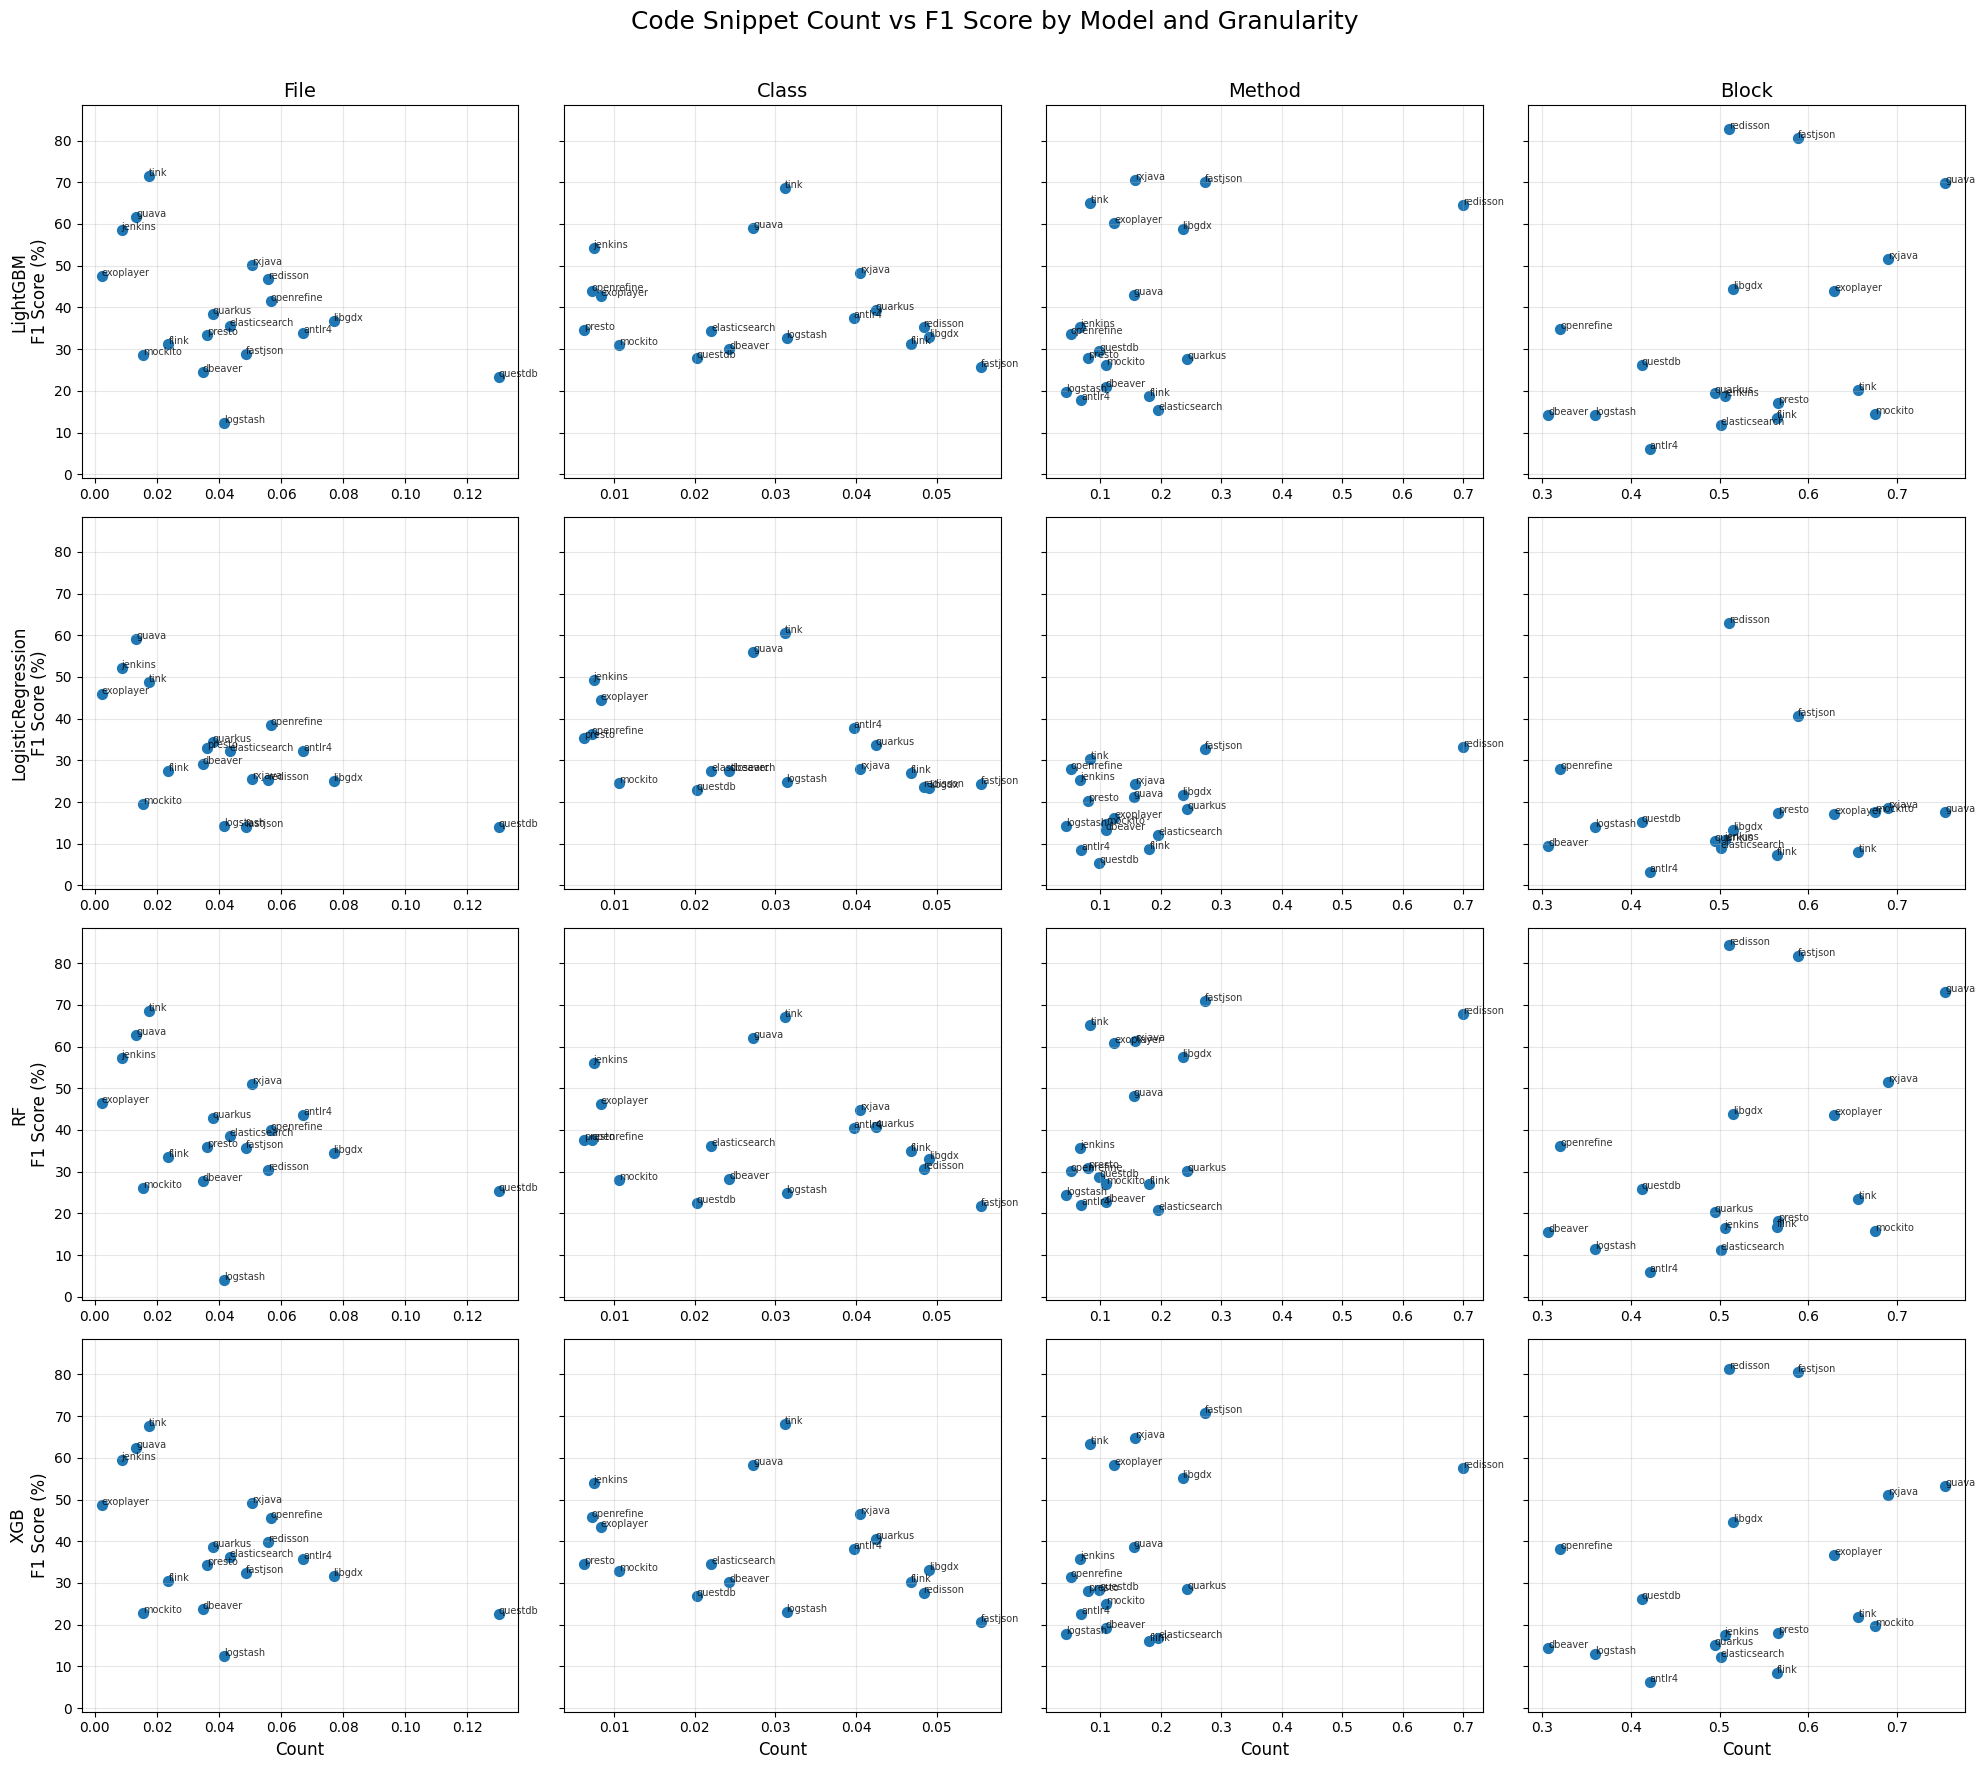

In [7]:
import matplotlib.pyplot as plt
import re

# Order of rows and columns
models = ["LightGBM", "LogisticRegression", "RF", "XGB"]
granularities = ["file", "class", "method", "block"]

# Function to convert LaTeX percentage strings to floats
def parse_percent(s):
    s = s.replace("\\enspace", "")
    s = s.replace("\\%", "")
    return float(re.sub(r"\s+", "", s))

fig, axes = plt.subplots(
    nrows=len(models),
    ncols=len(granularities),
    figsize=(20, 18),
    sharex=False,
    sharey=True
)

for i, model in enumerate(models):
    for j, granularity in enumerate(granularities):

        ax = axes[i, j]

        counts_dict = dups_by_project[granularity]
        scores_dict = results_dict[model][granularity]

        # Keep projects in the same order
        projects = list(counts_dict.keys())

        x = [counts_dict[p]["duplicate_count"] / counts_dict[p]["length"] for p in projects]
        y = [parse_percent(scores_dict[p]) for p in projects]

        ax.scatter(x, y, s=50)

        # Optional: label each point
        for xx, yy, project in zip(x, y, projects):
            ax.annotate(
                project,
                (xx, yy),
                fontsize=7,
                alpha=0.8
            )

        if i == 0:
            ax.set_title(granularity.capitalize(), fontsize=14)

        if j == 0:
            ax.set_ylabel(f"{model}\nF1 Score (%)", fontsize=12)

        if i == len(models) - 1:
            ax.set_xlabel("Count", fontsize=12)

        ax.grid(alpha=0.3)

fig.suptitle("Code Snippet Count vs F1 Score by Model and Granularity", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()